<img src="https://cdn.jsdelivr.net/gh/maxischa/datacamp_test@bf9431e/ressources/img/logo_macmia.png" alt="Banque des Territoires · France 2030 · MACMIA" width="520">

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maxischa/datacamp_test/blob/main/bloc3_stats_v2/cours/seance2_cours.ipynb)

# Séance 3.2 — Comparer deux groupes — hasard ou vrai écart ?

**Cours** · durée : 4h (2h de cours, 2h d'exercices)

> ⚠️ **Avant de taper quoi que ce soit :** *Fichier → Enregistrer une copie dans Drive*. Sinon votre travail sera perdu en fermant l'onglet.
>
> 📱 Sur tablette, faites d'abord les réglages de [Bien démarrer](https://github.com/maxischa/datacamp_test/blob/main/ressources/setup_tablette.md).

## Objectifs

À la fin de cette séance, vous saurez :

- expliquer pourquoi une moyenne calculée sur un échantillon n'est jamais exacte
- construire un intervalle de confiance à 95 % par rééchantillonnage
- comparer deux groupes avec un test t et lire sa p-value
- distinguer « pas de différence » de « pas de différence détectable »
- repérer les deux pièges qui rendent un test faux : dépendance des observations et tests répétés

## Une décision à 11 euros près

Le budget marketing de l'an prochain va sur **un seul** des deux marchés,
France ou Allemagne. Vous avez les paniers moyens.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Affichage adapte aux petits ecrans
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 80)

# Les donnees sont lues directement depuis le web : rien a telecharger
BASE = "https://cdn.jsdelivr.net/gh/maxischa/datacamp_test@bf9431e/bloc3_stats/data/"

In [2]:
cmd = pd.read_csv(BASE + "commandes.csv")

fr = cmd.query("pays == 'France'")["ca"]
de = cmd.query("pays == 'Allemagne'")["ca"]

print("France    :", round(fr.mean(), 2), "euros sur", len(fr), "commandes")
print("Allemagne :", round(de.mean(), 2), "euros sur", len(de), "commandes")

France    : 529.58 euros sur 253 commandes
Allemagne : 540.29 euros sur 252 commandes


**529,58 € contre 540,29 €.** L'Allemagne gagne de 10,71 €.

Prenez la décision maintenant, mentalement. On y revient à la fin de la
séance.

## 1. Quantifier l'incertitude d'une moyenne

Ces 253 commandes françaises ne sont pas « la France ». C'est **une année de
commandes** parmi toutes celles qui auraient pu se produire. Une autre année,
les mêmes clients auraient commandé un peu autrement, et la moyenne serait
différente.

**De combien ?** C'est exactement ça, quantifier l'incertitude d'une moyenne :
donner l'ordre de grandeur de ce que le hasard de l'échantillon peut faire
bouger. On peut le mesurer sans aucune formule, avec une seule méthode :
**rejouer l'échantillon**.

> 📖 **Cette méthode s'appelle le bootstrap.** Elle sert à mesurer la précision
> d'un chiffre calculé sur un échantillon — ici une moyenne — sans aucune
> hypothèse sur la forme des données. Son principe : faute de pouvoir refaire
> l'année, on rejoue l'échantillon lui-même en tirant dedans **avec remise**,
> et on regarde de combien le chiffre bouge. C'est le nom à connaître : tout
> logiciel de statistique le propose sous cette étiquette, et c'est de lui que
> vient le `boot` de nos variables.
> [Wikipédia](https://fr.wikipedia.org/wiki/Bootstrap_%28statistiques%29)

### L'outil : `sample()`

`sample` tire des observations au hasard dans une colonne **ou dans un
tableau entier** — on s'en servira des deux façons aujourd'hui.

In [3]:
# 5 valeurs tirees au hasard parmi les 253 commandes francaises
print(fr.sample(5, replace=True, random_state=0).round(2).tolist())
print(fr.sample(5, replace=True, random_state=1).round(2).tolist())

[361.76, 200.72, 662.35, 490.19, 3243.13]
[321.56, 491.12, 1130.95, 669.2, 244.65]


Trois arguments, et ils comptent tous les trois :

| Argument | Ce qu'il fait |
|---|---|
| le premier nombre | combien d'observations on tire |
| `replace=True` | tirage **avec remise** : une même commande peut sortir deux fois, une autre pas du tout |
| `random_state=0` | fixe le hasard, pour que tout le monde obtienne les mêmes valeurs |

La remise est le point clé. Sans elle, tirer 253 valeurs parmi 253 redonnerait
les 253 mêmes commandes dans le désordre — donc toujours la même moyenne, et
aucune information sur l'incertitude. Avec remise, chaque tirage est **une
année plausible** : les mêmes clients, un déroulé un peu différent.

> ⚠️ `random_state` n'a rien de statistique. C'est un numéro qui rend le
> tirage reproductible : même numéro, mêmes valeurs, sur n'importe quelle
> machine. On le fera varier de 0 à 999 pour obtenir mille tirages différents.

Oublier `replace=True` est l'erreur classique, et pandas la signale. La
cellule suivante est volontairement fausse : elle demande 1 000 valeurs à une
colonne qui n'en contient que 253, sans autoriser la remise.

In [4]:
fr.sample(1000)   ## erreur volontaire : il manque replace=True

ValueError: Cannot take a larger sample than population when 'replace=False'

Dernière ligne :

```
ValueError: Cannot take a larger sample than population when 'replace=False'
```

Traduction : sans remise, on ne peut pas tirer plus de valeurs qu'il n'y en a
dans la colonne. **Seule la dernière ligne d'une erreur compte.**

### Mille années plausibles

On tire donc 253 commandes avec remise parmi ces 253-là, on calcule la
moyenne, et on recommence mille fois.

La boucle les empile dans une **liste**, comme au bloc 1. Une liste sait
s'allonger, et c'est à peu près tout : elle ne sait ni se résumer, ni se
trier, ni se tracer. D'où la dernière ligne, `pd.Series(moyennes)`, qui la
transforme en **colonne pandas** — du même genre que `ventes["prix"]`. Rien
n'est calculé, on change d'objet pour récupérer l'outillage :

| Sur la liste | Sur la Series |
|---|---|
| `len(moyennes)` | `.min()`, `.max()`, `.mean()` |
| et c'est tout | `.quantile(0.025)`, et `.plot(kind="hist")` |

C'est le réflexe : **dès qu'une boucle a fini d'empiler des résultats, on en
fait une Series avant de les regarder.** Les trois cellules qui suivent ne font
que ça.

In [5]:
# 1 000 tirages, 1 000 moyennes : random_state=i change le tirage
moyennes = []
for i in range(1000):
    moyennes.append(fr.sample(len(fr), replace=True, random_state=i).mean())

boot = pd.Series(moyennes)   ## la liste devient une colonne pandas

print("la moyenne francaise varie de", round(boot.min(), 2),
      "a", round(boot.max(), 2))

la moyenne francaise varie de 410.98 a 730.7


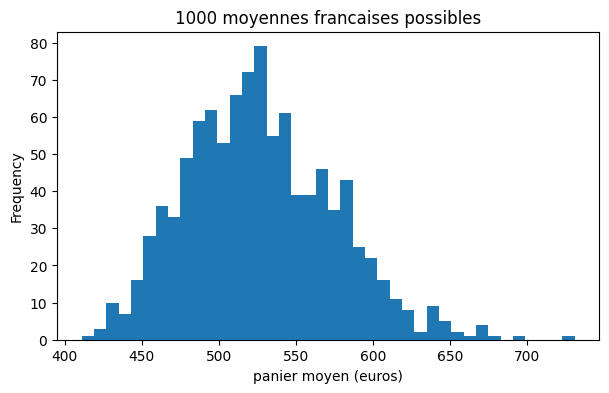

In [6]:
boot.plot(kind="hist", bins=40, figsize=(7, 4))   ## la forme du doute
plt.title("1000 moyennes francaises possibles")
plt.xlabel("panier moyen (euros)")
plt.show()

De **411 €** à **731 €**. Les mêmes clients, la même activité — et 320 €
d'écart entre la plus basse et la plus haute des moyennes plausibles.

L'écart franco-allemand que vous vouliez arbitrer était de **11 €**. Il tient
trente fois dans l'incertitude de la seule moyenne française.

## 2. L'intervalle de confiance à 95 %

On garde les **95 % centraux** de ces mille moyennes : on jette les 2,5 % les
plus basses et les 2,5 % les plus hautes.

In [7]:
bas = boot.quantile(0.025)    ## on jette les 2,5 % les plus basses
haut = boot.quantile(0.975)   ## et les 2,5 % les plus hautes

print("panier moyen francais : entre", round(bas, 2), "et", round(haut, 2))

panier moyen francais : entre 444.51 et 628.8


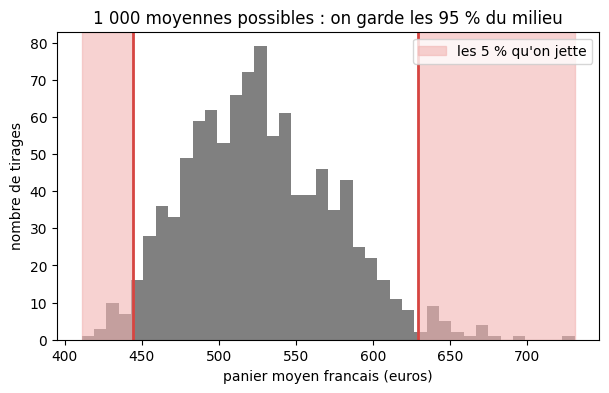

In [8]:
boot.plot(kind="hist", bins=40, figsize=(7, 4), color="grey")   ## les 1 000 moyennes

# axvspan = une BANDE verticale, d'une valeur a une autre. Ici les deux
# queues qu'on ecarte : du minimum a `bas`, puis de `haut` au maximum.
plt.axvspan(boot.min(), bas, color="#F2B5B3", alpha=0.6)   ## alpha : l'histogramme reste visible dessous
plt.axvspan(haut, boot.max(), color="#F2B5B3", alpha=0.6,
            label="les 5 % qu'on jette")   ## un seul label : la legende ne repete pas la meme entree
plt.axvline(bas, color="#D64541", linewidth=2)    ## axvline = un TRAIT vertical : les deux bornes
plt.axvline(haut, color="#D64541", linewidth=2)   ## de la fourchette, calculees juste au-dessus
plt.title("1 000 moyennes possibles : on garde les 95 % du milieu")
plt.xlabel("panier moyen francais (euros)")   ## la grandeur ET son unite
plt.ylabel("nombre de tirages")               ## un histogramme compte : ici, des tirages
plt.legend()   ## affiche le label ci-dessus, sinon le rose ne dit rien
plt.show()

**445 € à 629 €.** Les zones roses sont ce qu'on écarte : les 25 tirages les plus
bas et les 25 les plus hauts. Ne reste que le milieu, et c'est ça, l'intervalle
de confiance à 95 %.

> 💡 **Comment on le dit.** « Compte tenu de ce qu'on a observé, les valeurs
> plausibles du panier moyen français vont de 445 € à 629 €. » C'est une
> **fourchette de plausibilité**, pas une probabilité sur la vraie valeur.

Et l'Allemagne ?

In [9]:
moyennes_de = []
for i in range(1000):
    moyennes_de.append(de.sample(len(de), replace=True, random_state=i).mean())

bd = pd.Series(moyennes_de)

print("France    :", round(bas, 2), "-", round(haut, 2))
print("Allemagne :", round(bd.quantile(0.025), 2), "-", round(bd.quantile(0.975), 2))

France    : 444.51 - 628.8
Allemagne : 460.8 - 641.21


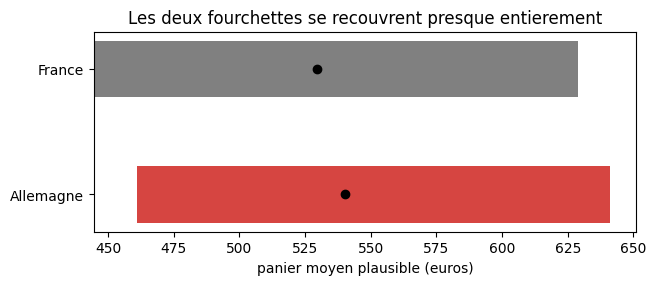

In [10]:
bas_de, haut_de = bd.quantile(0.025), bd.quantile(0.975)   ## fourchette allemande

plt.figure(figsize=(7, 2.6))   ## figure basse : deux barres, rien d'autre a loger

# barh(etiquettes, LONGUEURS) : la longueur d'une barre est la LARGEUR de la
# fourchette, pas sa position. C'est `left` qui dit ou chacune commence.
plt.barh(["Allemagne", "France"], [haut_de - bas_de, haut - bas],
         left=[bas_de, bas],           ## la borne basse de chaque fourchette
         color=["#D64541", "grey"],    ## une couleur par barre, dans le meme ordre
         height=0.45)                  ## barres fines : l'oeil compare deux segments
plt.scatter([de.mean(), fr.mean()], ["Allemagne", "France"],
            color="black", zorder=5)   ## zorder=5 : les points passent PAR-DESSUS les barres
plt.xlabel("panier moyen plausible (euros)")
plt.title("Les deux fourchettes se recouvrent presque entierement")
plt.show()

**445–629 contre 461–641.** La réponse à la question de départ, en une image :
les deux barres se recouvrent sur **168 € des 184 €** de la fourchette
française, soit **91 %**. Les deux points noirs — les moyennes observées, 530 €
et 540 € — tombent chacun à l'intérieur de l'autre fourchette.

Il n'y a rien à arbitrer entre ces deux marchés sur la base du panier moyen.
**L'écart de 11 € que vous vouliez transformer en budget est plus petit que
l'épaisseur de la mesure.**

## 3. Le test t : la même question, en un nombre

### D'abord, d'où vient `stats` ?

La cellule de setup a chargé une ligne de plus que d'habitude :

```python
from scipy import stats
```

**SciPy** est la bibliothèque de calcul scientifique de Python, l'étage
au-dessus de numpy. Elle rassemble ce qu'aucun analyste ne réécrit lui-même :
optimisation, algèbre linéaire, traitement du signal — et `scipy.stats`, son
module de statistiques.

C'est celui-là, et lui seul, qui nous intéresse : `from scipy import stats`
ne charge que cette partie. Il contient les lois de probabilité et **tous les
tests statistiques du cours** — `ttest_ind` aujourd'hui, d'autres au bloc 5.
Comme pandas et matplotlib, il est déjà installé dans Colab : rien à faire.

| La bibliothèque | Ce qu'on lui demande |
|---|---|
| `pandas` | manipuler le tableau |
| `matplotlib` | le mettre en image |
| `scipy.stats` | y appliquer un test |

Une ligne de setup en plus, donc, et seulement dans les séances qui en ont
besoin.

### Le test

Le test répond exactement à la question qu'on vient de se poser :

> **Si les deux marchés étaient identiques, à quelle fréquence observerait-on
> un écart au moins aussi grand que celui-ci ?**

Cette fréquence, c'est la **p-value**.

> 📖 **`equal_var=False`, c'est le test de Welch.** Même question — cet écart de
> moyennes est-il compatible avec le hasard ? — mais sans supposer que les deux
> groupes ont la **même dispersion**. Ici les deux se ressemblent (765 € et
> 751 €) et les deux versions donnent la même p-value ; quand elles diffèrent
> nettement, la version qui les suppose égales peut annoncer une certitude
> qu'elle n'a pas.
>
> **C'est pourquoi on l'écrit à chaque fois.** SciPy, lui, fait le choix
> inverse : sans cet argument, `ttest_ind` suppose les dispersions égales.
> [Wikipédia](https://fr.wikipedia.org/wiki/Test_de_Student)

In [11]:
# equal_var=False : on ne suppose pas la meme dispersion des deux cotes.
# Ce n'est PAS le comportement par defaut de scipy : d'ou l'argument, a
# chaque appel.
resultat = stats.ttest_ind(fr, de, equal_var=False)

print("p-value :", round(resultat.pvalue, 3))   ## 0,874 : rien a retenir

p-value : 0.874


**p = 0,874.** Si les deux marchés étaient identiques, on observerait un écart
d'au moins 11 € dans **87 % des cas**. Cet écart n'a rien de remarquable.

La convention : on retient un écart quand **p < 0,05**.

| p-value | Ce qu'on en fait |
|---|---|
| p < 0,05 | l'écart serait rare sous l'hypothèse d'égalité : on le retient |
| p ≥ 0,05 | l'écart est compatible avec le hasard : **on ne conclut rien** |

> ⚠️ **La faute à ne pas commettre.** p = 0,874 ne dit **pas** que les deux
> marchés sont identiques. Il dit que ces données ne permettent pas de les
> départager. Avec 5 000 commandes de chaque côté, le même écart de 11 €
> pourrait très bien devenir significatif.
>
> « Pas de différence détectable » et « pas de différence » sont deux
> affirmations différentes.

Le seuil de 0,05 est une **convention**, pas une loi de la nature. Une p-value
de 0,049 et une de 0,051 décrivent à peu près la même situation.

## 4. Un cas où le test tranche — et le piège qui va avec

Même test, Royaume-Uni contre Irlande.

In [12]:
uk = cmd.query("pays == 'Royaume-Uni'")["ca"]
irl = cmd.query("pays == 'Irlande'")["ca"]

print("p-value :", stats.ttest_ind(uk, irl, equal_var=False).pvalue)   ## minuscule

p-value : 1.4245236404057462e-08


**p = 0,000000014.** Un écart comme celui-là ne s'explique pas par le hasard.
Le panier irlandais est réellement plus élevé.

Avant d'écrire la recommandation, une question : **combien de personnes** y
a-t-il derrière ces commandes ?

In [14]:
cmd.groupby("pays")["client_id"].nunique().nlargest(4)   ## des GENS

,client_id
pays,
Royaume-Uni,235
France,52
Allemagne,51
Belgique,18


**Deux clients irlandais.** Contre 235 britanniques.

Le test t suppose que les observations sont **indépendantes** : que chaque
commande apporte une information nouvelle. Ici, 256 commandes viennent de
deux acheteurs. Ce ne sont pas 256 comportements d'achat, ce sont **deux**,
répétés 128 fois chacun en moyenne.

La p-value a été calculée comme s'il y en avait 256. Elle est donc beaucoup
trop optimiste — et elle l'est dans le sens qui vous plaît.

> ⚠️ **Avant tout test : comptez les individus, pas les lignes.** C'est le
> même réflexe `nunique` qu'en séance 2.3, et il a la même importance ici.

## 5. Significatif ne veut pas dire important

Un test dit si un écart existe. Il ne dit rien de sa **taille**, et c'est la
taille qui fait la décision.

In [13]:
print("ecart :", round(irl.mean() - uk.mean(), 2), "euros")   ## la taille
print("rapport :", round(irl.mean() / uk.mean(), 2), "fois plus")

ecart : 626.46 euros
rapport : 2.59 fois plus


626 € d'écart, un panier 2,6 fois plus élevé : ici l'effet est énorme *et*
significatif.

Mais l'inverse arrive tout le temps : sur 100 000 commandes, un écart de 3 €
sort avec p < 0,001. Statistiquement indiscutable, commercialement sans
intérêt. **Affichez toujours l'écart en euros à côté de la p-value.**

## 6. Tests répétés : chercher jusqu'à trouver finit toujours par trouver

Revenons sur le seuil de 0,05. On l'a présenté comme une convention ; c'est
aussi, très concrètement, un **taux d'erreur accepté d'avance**.

Relisez la définition : la p-value est la probabilité d'observer un écart au
moins aussi grand que celui-ci **si les deux groupes étaient identiques**.
Retenir tout ce qui passe sous 0,05, c'est donc accepter que, sur des groupes
réellement identiques, **un test sur vingt** annonce quand même une
différence. Ce n'est pas un défaut de la méthode : c'est le contrat qu'on a
signé en choisissant ce seuil.

### L'intuition : que devient ce contrat quand on lance vingt tests ?

Sur des groupes identiques, un test a 95 % de chances de rester silencieux.
Deux tests indépendants : 0,95 × 0,95. Vingt tests : 0,95 puissance 20.

In [15]:
aucun_faux = 0.95 ** 20   ## les 20 tests restent silencieux
print("probabilite qu'aucun ne crie :", round(100 * aucun_faux, 1), "%")
print("donc au moins un faux positif :", round(100 * (1 - aucun_faux), 1), "%")

probabilite qu'aucun ne crie : 35.8 %
donc au moins un faux positif : 64.2 %


**64 %.** En lançant vingt tests sur des groupes entre lesquels il n'y a
strictement rien à trouver, on a **deux chances sur trois** d'en voir sortir
au moins un « significatif ».

Ni 5 % — le seuil vaut pour **un** test, pas pour une campagne — ni 100 % :
c'est une probabilité, pas une fatalité. Et le chiffre grimpe vite : 5 tests
→ 23 %, 100 tests → 99 %. Un tableau de bord qui compare tout seul dix segments
sur dix indicateurs lance cent tests par semaine.

### La vérification, sur ce fichier

Vingt comparaisons entre deux moitiés du fichier tirées **au hasard**. Les
deux moitiés sortent de la même population : par construction, il n'y a
**aucune** différence à trouver.

In [16]:
ps = []
for i in range(20):
    a = cmd.sample(frac=0.5, random_state=i)   ## une moitie au hasard
    b = cmd.drop(a.index)                      ## l'autre moitie
    ps.append(stats.ttest_ind(a["ca"], b["ca"], equal_var=False).pvalue)

ps = pd.Series(ps)
print("plus petite p-value :", round(ps.min(), 4), "| nombre sous 0,05 :", (ps < 0.05).sum())

plus petite p-value : 0.0244 | nombre sous 0,05 : 1


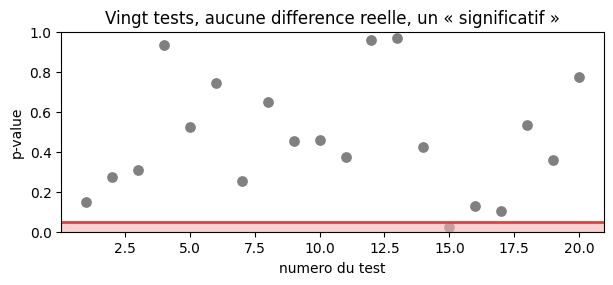

In [17]:
plt.figure(figsize=(7, 2.6))   ## figure basse : vingt points sur une seule echelle

# scatter(x, y) : un point par test. ps.index vaut 0 a 19, d'ou le +1 pour
# numeroter les tests de 1 a 20 ; s = la taille des points.
plt.scatter(ps.index + 1, ps, color="grey", s=45)

# axhspan = une bande HORIZONTALE (axvspan etait verticale) : de 0 a 0,05
plt.axhspan(0, 0.05, color="#F2B5B3", alpha=0.6)   ## la zone « significatif »
plt.axhline(0.05, color="#D64541", linewidth=2)    ## le seuil lui-meme, en trait plein
plt.ylim(0, 1)   ## l'axe va de 0 a 1 : une p-value ne sort jamais de la
plt.xlabel("numero du test")
plt.ylabel("p-value")
plt.title("Vingt tests, aucune difference reelle, un « significatif »")
plt.show()

**Vingt points, une bande rouge, et un seul point dedans** : le quinzième, à
p = 0,024. Les deux moitiés comparées sortent du même fichier, tirées au
hasard — il n'y a, par construction, rien à trouver.

Maintenant, cachez les dix-neuf autres points. Ce qui reste est un résultat
significatif, correctement calculé, sur des données réelles. Et faux.

**Un test sur vingt ressort à p = 0,024** — exactement ce que la probabilité
annonçait, et une différence qui n'existe pas.

Imaginez maintenant qu'on ne vous montre que celui-là. La p-value est juste,
le calcul est correct, le graphique sera convaincant, et la conclusion sera
fausse. **Ce qui manque n'est pas dans le résultat : c'est le nombre de tests
qu'il a fallu lancer pour l'obtenir.**

> ⚠️ **La règle : la question d'abord, le test ensuite.** Une p-value ne vaut
> que pour un test décidé **avant** d'avoir regardé les données. Si vous en
> avez lancé vingt, dites-le — et durcissez le seuil en conséquence. La
> correction la plus simple, dite **de Bonferroni**, divise le seuil par le
> nombre de tests : 0,05 / 20 = 0,0025. Notre p-value de 0,024 ne passe plus
> du tout.

> 📖 **La correction de Bonferroni.** Elle répond à : comment tenir un risque de
> fausse alerte de 5 % sur **l'ensemble** d'une campagne de tests, et non sur
> chacun pris à part ? Sa méthode : partager ce budget de 5 % entre les tests,
> donc diviser le seuil par leur nombre. Ce qu'elle coûte : elle est
> délibérément sévère, et un écart réel mais modeste cesse d'être détectable.
> Moins de fausses alertes, mais plus d'occasions manquées.
> [Wikipédia](https://fr.wikipedia.org/wiki/Correction_de_Bonferroni)

### Alors, France ou Allemagne ?

Aucune des deux, sur ce critère. L'écart de 11 € n'est pas mesurable avec
250 commandes de chaque côté. Il faut arbitrer sur autre chose — le coût
d'acquisition, la marge, la logistique — ou récolter plus de données.

**Dire « ces données ne permettent pas de trancher » est une réponse
professionnelle.** C'est souvent la bonne.

---

## Ce que vous savez faire maintenant

| Vous voulez... | La commande |
|---|---|
| un rééchantillon | `serie.sample(len(serie), replace=True, random_state=i)` |
| analyser une liste de résultats | `pd.Series(ma_liste)` |
| l'intervalle de confiance à 95 % | `boot.quantile(0.025)` et `boot.quantile(0.975)` |
| comparer deux moyennes | `stats.ttest_ind(a, b, equal_var=False)` |
| la p-value seule | `stats.ttest_ind(a, b, equal_var=False).pvalue` |
| compter les individus derrière un groupe | `df.groupby("pays")["client_id"].nunique()` |
| le risque d'au moins un faux positif sur n tests | `1 - 0.95 ** n` |

## Lire une p-value

| p-value | Ce qu'on peut dire |
|---|---|
| **inférieure à 0,05** | l'écart observé serait rare si les deux groupes étaient identiques : on le retient |
| **supérieure à 0,05** | l'écart est compatible avec le hasard : **on ne conclut rien** |

## Les trois phrases à retenir

1. **« On ne peut pas conclure » n'est pas « il n'y a pas de différence ».**
   Avec 253 et 252 commandes, on ne détecte pas un écart de 11 €. Cela ne
   prouve pas qu'il est nul.

2. **Un test suppose des observations indépendantes.** 256 commandes
   irlandaises passées par **2 clients** ne sont pas 256 observations
   indépendantes, quelle que soit la p-value affichée.

3. **Une p-value n'est valable que pour le test qu'on avait prévu de faire.**
   Sur des groupes identiques, vingt tests ont **64 %** de chances d'en sortir
   un « significatif ». Par construction : c'est le seuil lui-même qu'on a
   retrouvé, pas un résultat.